In [1]:
# ============================================================
# Intelligent Book Recommendation System
# File: preprocessing.py
# Purpose: Data Cleaning and Text Preprocessing
# ============================================================

import pandas as pd
import numpy as np
import re
import ast
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


# ------------------------------------------------------------
# Download NLTK resources (first run only)
# ------------------------------------------------------------

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

DATASET = "/Users/brajeshmishra/Downloads/book_dataset.csv"

df = pd.read_csv(DATASET)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(df.head())

# ------------------------------------------------------------
# Dataset Information
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ------------------------------------------------------------
# Remove Duplicates
# ------------------------------------------------------------

before = len(df)

df.drop_duplicates(subset=["title"], inplace=True)

after = len(df)

print(f"\nDuplicates Removed : {before-after}")

# ------------------------------------------------------------
# Handle Missing Values
# ------------------------------------------------------------

important_columns = [
    "title",
    "description",
    "genres",
    "author"
]

df.dropna(subset=important_columns, inplace=True)

df.reset_index(drop=True, inplace=True)

print("\nRemaining Records :", len(df))

# ------------------------------------------------------------
# Convert List Columns to Text
# ------------------------------------------------------------

def convert_list(text):
    """
    Convert string representation of list
    into plain text.

    Example:
    "['Fantasy','Adventure']"

    becomes

    Fantasy Adventure
    """

    if pd.isna(text):
        return ""

    try:
        value = ast.literal_eval(text)

        if isinstance(value, list):
            return " ".join(str(i) for i in value)

        return str(value)

    except:
        return str(text)


df["genres"] = df["genres"].apply(convert_list)
df["author"] = df["author"].apply(convert_list)

# ------------------------------------------------------------
# Text Cleaning
# ------------------------------------------------------------

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """
    Text preprocessing pipeline.
    """

    if pd.isna(text):
        return ""

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = re.sub(r"\s+", " ", text)

    tokens = word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)


print("\nCleaning Description...")

df["clean_description"] = df["description"].apply(clean_text)

print("Cleaning Genres...")

df["clean_genres"] = df["genres"].apply(clean_text)

print("Cleaning Authors...")

df["clean_author"] = df["author"].apply(clean_text)

# ------------------------------------------------------------
# Combine Text Features
# ------------------------------------------------------------

df["combined_text"] = (
    df["clean_genres"]
    + " "
    + df["clean_author"]
    + " "
    + df["clean_description"]
)

# ------------------------------------------------------------
# Remove Empty Records
# ------------------------------------------------------------

df = df[df["combined_text"].str.strip() != ""]

df.reset_index(drop=True, inplace=True)

# ------------------------------------------------------------
# Final Dataset Summary
# ------------------------------------------------------------

print("\nFinal Dataset Shape")

print(df.shape)

print("\nSample Combined Text\n")

print(df["combined_text"].head())

# ------------------------------------------------------------
# Save Cleaned Dataset
# ------------------------------------------------------------

OUTPUT_FILE = "cleaned_books.csv"

df.to_csv(OUTPUT_FILE, index=False)

print("\nCleaned Dataset Saved Successfully")

print(OUTPUT_FILE)

print("\nPreprocessing Completed.")

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/brajeshmishra/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/brajeshmishra/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/brajeshmishra/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/brajeshmishra/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset Loaded Successfully
                     title                         titleComplete  \
0        Project Hail Mary                     Project Hail Mary   
1  The Talented Mr. Ripley  The Talented Mr. Ripley (Ripley, #1)   
2           More Than This                        More Than This   
3       After Forever Ends                    After Forever Ends   
4     A Bird Without Wings                  A Bird Without Wings   

                                         description  \
0  Ryland Grace is the sole survivor on a despera...   
1  Since his debut in 1955, Tom Ripley has evolve...   
2  A boy drowns, desperate and alone in his final...   
3  Orphaned by her mother and brushed off by her ...   
4  After an impoverished and indigent childhood, ...   

                                              genres        isbn  \
0  ['Science Fiction Fantasy', 'Audiobook', 'Fant...  0593135202   
1  ['Novels', 'Noir', 'Classics', 'Italy', 'Suspe...  0393332144   
2  ['Queer', 'Fantasy'

Exploratory Data Analysis

Dataset Shape:
(11960, 18)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 11960 entries, 0 to 11959
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              11960 non-null  str    
 1   titleComplete      11960 non-null  str    
 2   description        11960 non-null  str    
 3   genres             11960 non-null  str    
 4   isbn               9526 non-null   str    
 5   publisher          11389 non-null  str    
 6   author             11960 non-null  str    
 7   characters         5468 non-null   str    
 8   places             4619 non-null   str    
 9   ratingHistogram    11957 non-null  str    
 10  ratingsCount       11957 non-null  float64
 11  reviewsCount       11940 non-null  float64
 12  numPages           11738 non-null  float64
 13  language           11654 non-null  str    
 14  clean_description  11874 non-null  str    
 15  clean

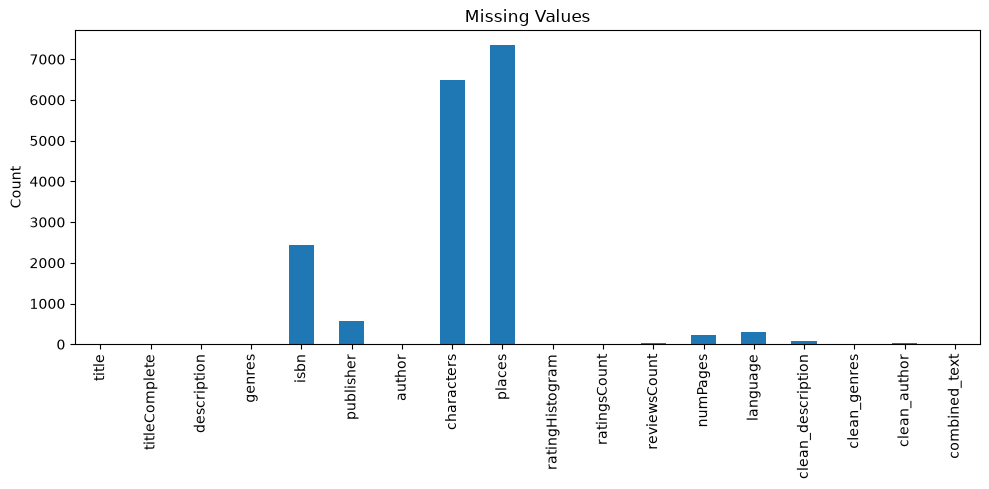

/var/folders/4f/p15pstxn68l065217fqfzh2h0000gn/T/ipykernel_39216/2221585622.py:94: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


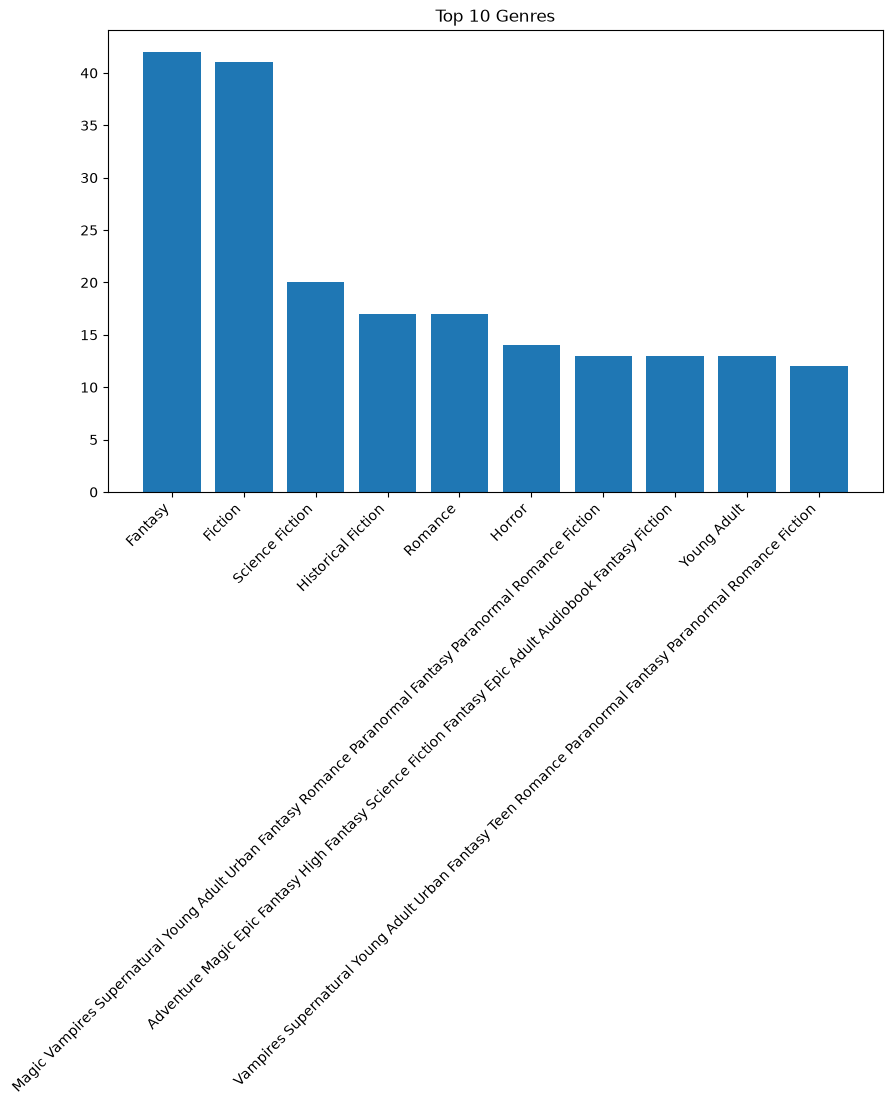

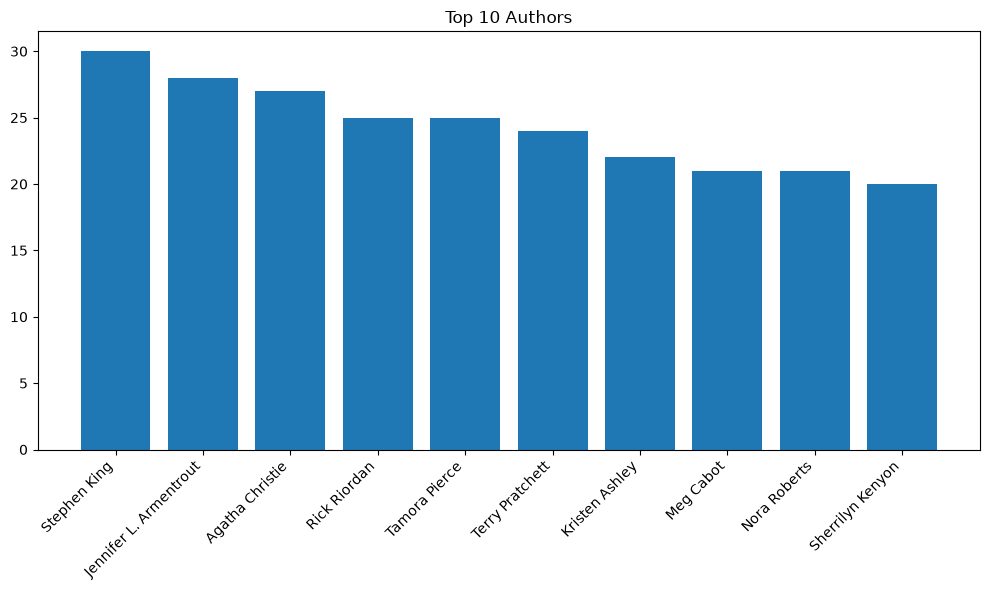

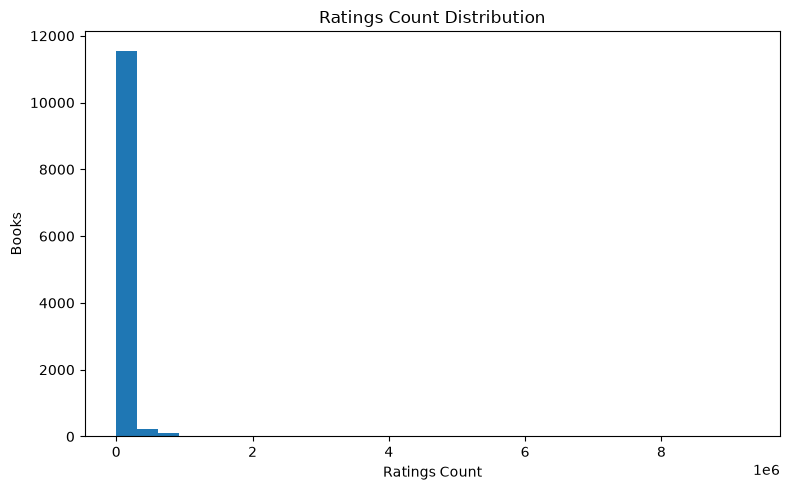

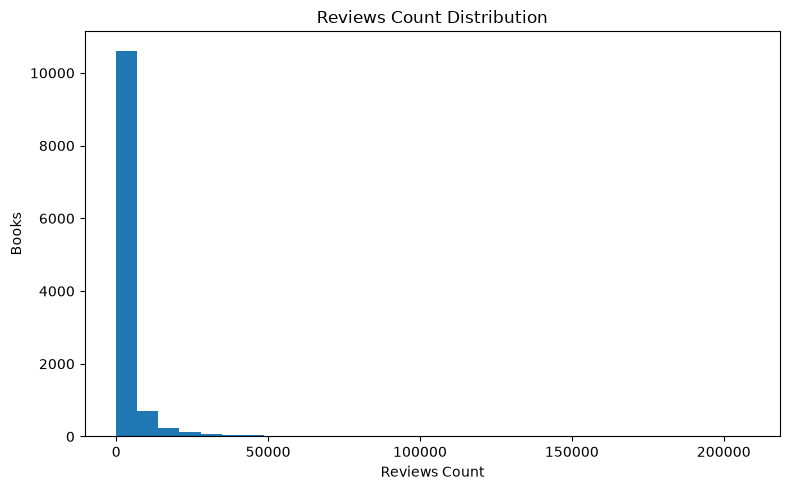

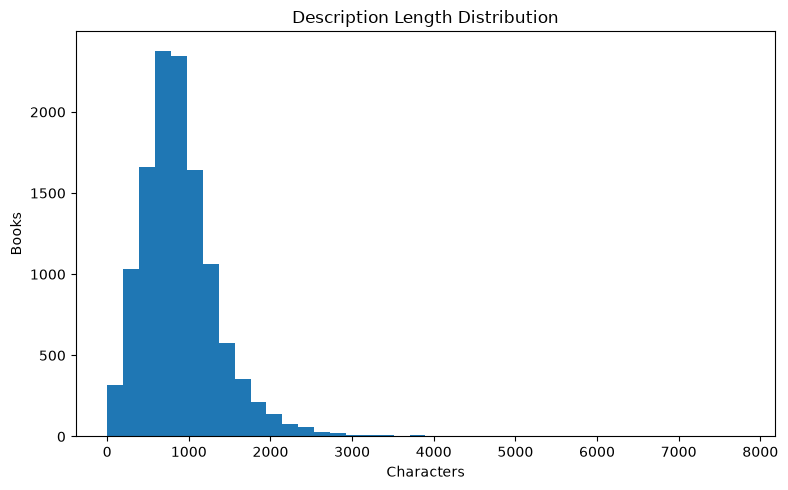

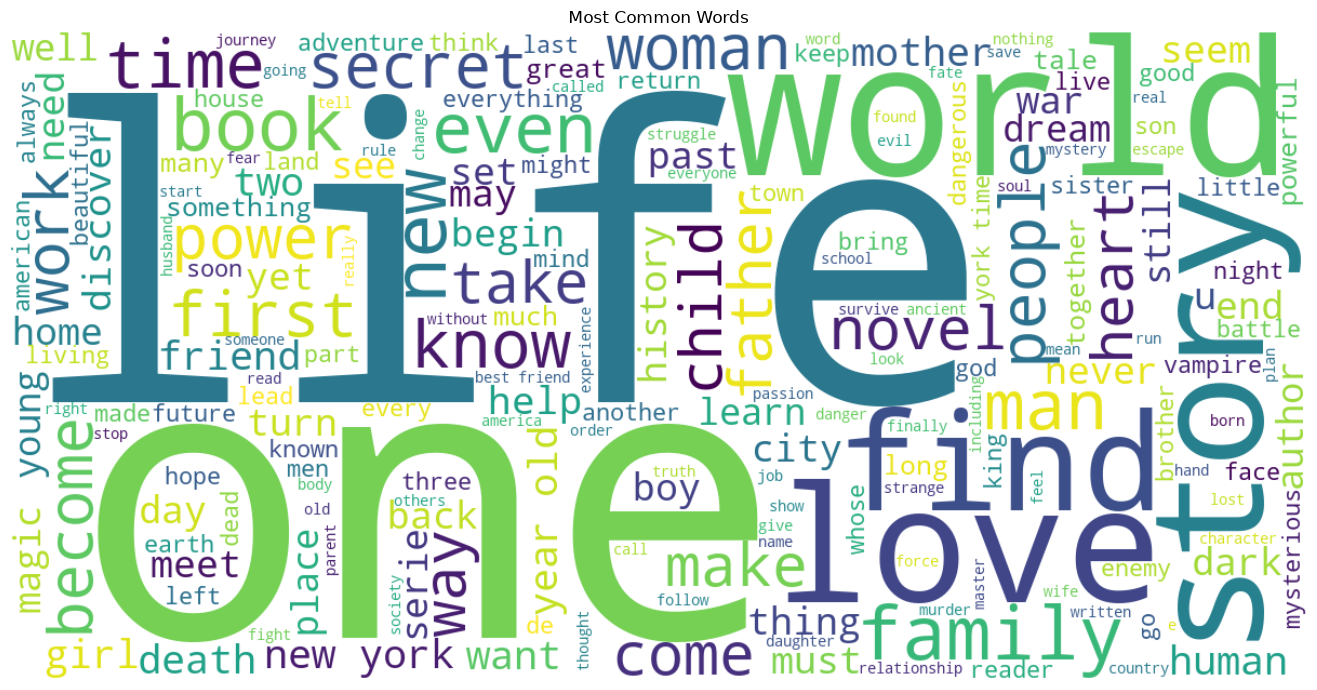

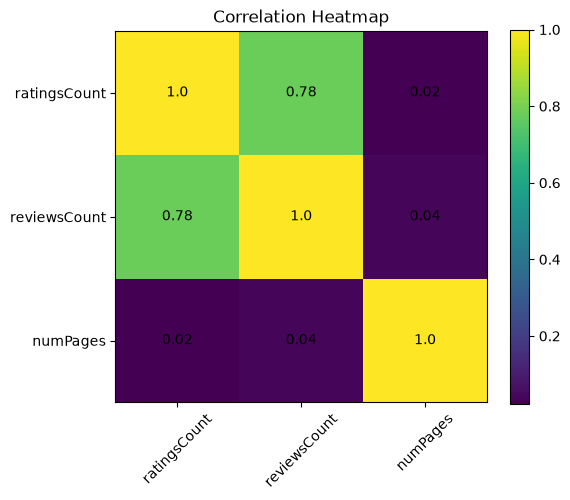

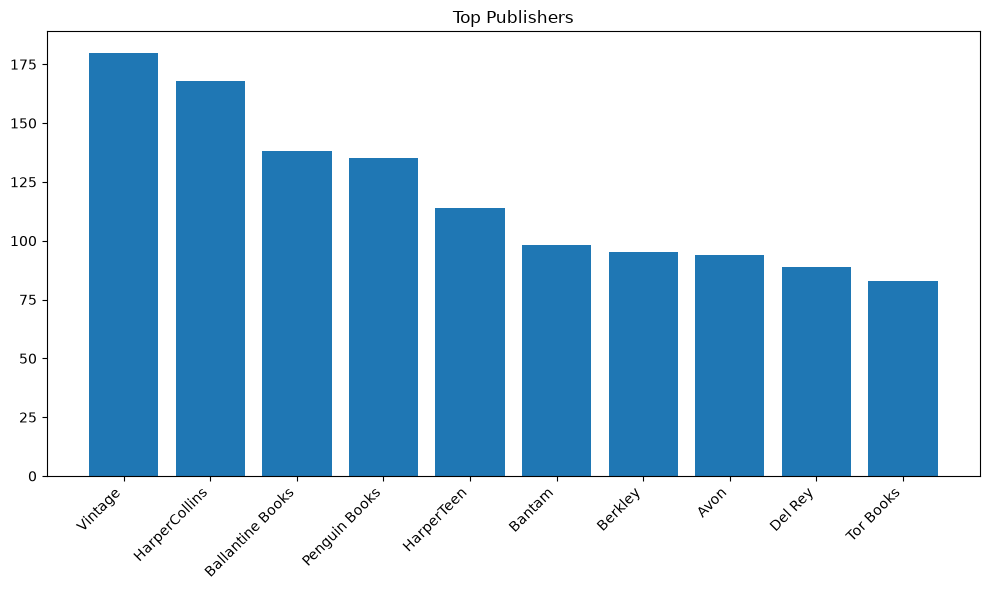

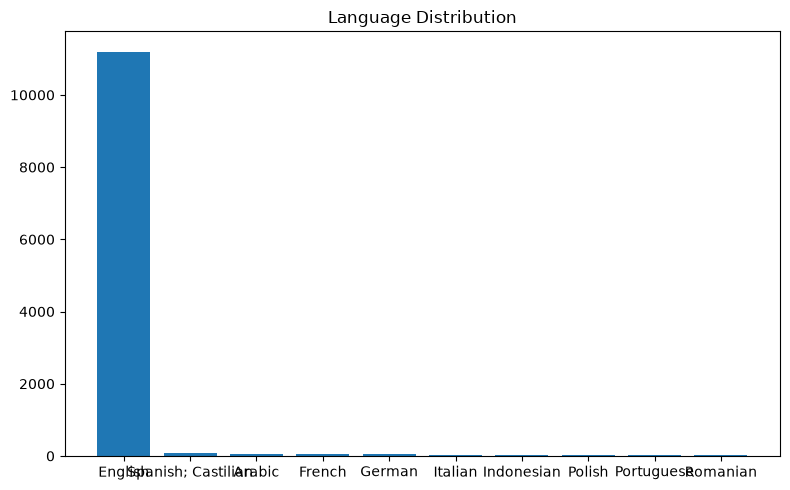



Recommendation Dataset Statistics
Total Books      : 11960
Unique Authors   : 7243
Unique Publishers: 3451
Average Description Length: 894.90

EDA Completed Successfully!

All graphs have been saved inside the 'images' folder.


In [4]:
# ============================================================
# Intelligent Book Recommendation System
# File: eda.py
# Purpose: Exploratory Data Analysis (EDA)
# ============================================================

import os
import ast
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# ------------------------------------------------------------
# Load Cleaned Dataset
# ------------------------------------------------------------

DATASET = "cleaned_books.csv"

df = pd.read_csv(DATASET)

print("=" * 60)
print("Exploratory Data Analysis")
print("=" * 60)

# ------------------------------------------------------------
# Create images folder
# ------------------------------------------------------------

os.makedirs("images", exist_ok=True)

# ------------------------------------------------------------
# Dataset Overview
# ------------------------------------------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nFirst Five Records:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe(include="all"))

# ------------------------------------------------------------
# Missing Values Visualization
# ------------------------------------------------------------

missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("images/missing_values.png")
plt.show()

# ------------------------------------------------------------
# Top Genres
# ------------------------------------------------------------

genre_counts = {}

for genres in df["genres"].dropna():
    try:
        genre_list = ast.literal_eval(genres) if genres.startswith("[") else genres.split(",")
    except:
        genre_list = genres.split(",")

    for g in genre_list:
        g = str(g).strip().replace("'", "").replace('"', "")
        if g != "":
            genre_counts[g] = genre_counts.get(g, 0) + 1

genre_df = (
    pd.DataFrame(
        genre_counts.items(),
        columns=["Genre", "Count"]
    )
    .sort_values("Count", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
plt.bar(genre_df["Genre"], genre_df["Count"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Genres")
plt.tight_layout()
plt.savefig("images/top_genres.png")
plt.show()

# ------------------------------------------------------------
# Top Authors
# ------------------------------------------------------------

author_counts = df["author"].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(author_counts.index, author_counts.values)
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Authors")
plt.tight_layout()
plt.savefig("images/top_authors.png")
plt.show()

# ------------------------------------------------------------
# Ratings Distribution
# ------------------------------------------------------------

if "ratingsCount" in df.columns:

    plt.figure(figsize=(8,5))
    plt.hist(df["ratingsCount"], bins=30)
    plt.title("Ratings Count Distribution")
    plt.xlabel("Ratings Count")
    plt.ylabel("Books")
    plt.tight_layout()
    plt.savefig("images/ratings_distribution.png")
    plt.show()

# ------------------------------------------------------------
# Reviews Distribution
# ------------------------------------------------------------

if "reviewsCount" in df.columns:

    plt.figure(figsize=(8,5))
    plt.hist(df["reviewsCount"], bins=30)
    plt.title("Reviews Count Distribution")
    plt.xlabel("Reviews Count")
    plt.ylabel("Books")
    plt.tight_layout()
    plt.savefig("images/reviews_distribution.png")
    plt.show()

# ------------------------------------------------------------
# Description Length
# ------------------------------------------------------------

df["description_length"] = df["description"].fillna("").apply(len)

plt.figure(figsize=(8,5))
plt.hist(df["description_length"], bins=40)
plt.title("Description Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Books")
plt.tight_layout()
plt.savefig("images/description_length.png")
plt.show()

# ------------------------------------------------------------
# Word Cloud
# ------------------------------------------------------------

text = " ".join(df["clean_description"].fillna(""))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words")
plt.tight_layout()
plt.savefig("images/wordcloud.png")
plt.show()

# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------

numeric_cols = []

for col in [
    "ratingsCount",
    "reviewsCount",
    "numPages"
]:
    if col in df.columns:
        numeric_cols.append(col)

if len(numeric_cols) >= 2:

    corr = df[numeric_cols].corr()

    plt.figure(figsize=(6,5))
    plt.imshow(corr)

    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
    plt.yticks(range(len(corr.columns)), corr.columns)

    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            plt.text(
                j,
                i,
                round(corr.iloc[i, j], 2),
                ha="center",
                va="center"
            )

    plt.colorbar()
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.savefig("images/correlation_heatmap.png")
    plt.show()

# ------------------------------------------------------------
# Top Publishers (Optional)
# ------------------------------------------------------------

if "publisher" in df.columns:

    publisher_counts = df["publisher"].value_counts().head(10)

    plt.figure(figsize=(10,6))
    plt.bar(
        publisher_counts.index,
        publisher_counts.values
    )

    plt.xticks(rotation=45, ha="right")
    plt.title("Top Publishers")
    plt.tight_layout()
    plt.savefig("images/top_publishers.png")
    plt.show()

# ------------------------------------------------------------
# Language Distribution (Optional)
# ------------------------------------------------------------

if "language" in df.columns:

    language_counts = df["language"].value_counts().head(10)

    plt.figure(figsize=(8,5))
    plt.bar(
        language_counts.index,
        language_counts.values
    )

    plt.title("Language Distribution")
    plt.tight_layout()
    plt.savefig("images/language_distribution.png")
    plt.show()

# ------------------------------------------------------------
# Recommendation Statistics
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("Recommendation Dataset Statistics")
print("=" * 60)

print(f"Total Books      : {len(df)}")
print(f"Unique Authors   : {df['author'].nunique()}")
print(f"Unique Publishers: {df['publisher'].nunique() if 'publisher' in df.columns else 'N/A'}")
print(f"Average Description Length: {df['description_length'].mean():.2f}")

print("\nEDA Completed Successfully!")

print("\nAll graphs have been saved inside the 'images' folder.")

In [3]:
# ============================================================
# Intelligent Book Recommendation System
# File: recommendation.py
# Purpose: Content-Based Book Recommendation Engine
# ============================================================

import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# Load Cleaned Dataset
# ------------------------------------------------------------

DATASET = "cleaned_books.csv"

df = pd.read_csv(DATASET)

print("=" * 60)
print("Book Recommendation Engine")
print("=" * 60)

# ------------------------------------------------------------
# Check Required Column
# ------------------------------------------------------------

if "combined_text" not in df.columns:
    raise ValueError(
        "combined_text column not found.\n"
        "Run preprocessing.py first."
    )

# ------------------------------------------------------------
# Bag of Words
# ------------------------------------------------------------

print("\nCreating Bag of Words Matrix...")

bow = CountVectorizer(
    max_features=5000,
    stop_words="english"
)

bow_matrix = bow.fit_transform(df["combined_text"])

print("BoW Shape :", bow_matrix.shape)

# ------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------

print("\nCreating TF-IDF Matrix...")

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

tfidf_matrix = tfidf.fit_transform(df["combined_text"])

print("TF-IDF Shape :", tfidf_matrix.shape)

# ------------------------------------------------------------
# Cosine Similarity
# ------------------------------------------------------------

print("\nCalculating Cosine Similarity...")

similarity_matrix = cosine_similarity(tfidf_matrix)

print("Similarity Matrix Shape :", similarity_matrix.shape)

# ------------------------------------------------------------
# Create Index Mapping
# ------------------------------------------------------------

indices = pd.Series(
    df.index,
    index=df["title"].str.lower()
).drop_duplicates()

# ------------------------------------------------------------
# Search Function
# ------------------------------------------------------------

def search_book(book_name):
    """
    Search for books using partial title matching.
    """

    matches = df[
        df["title"].str.contains(
            book_name,
            case=False,
            na=False
        )
    ]

    return matches[["title", "author"]]

# ------------------------------------------------------------
# Recommendation Function
# ------------------------------------------------------------

def recommend(book_title, top_n=10):
    """
    Recommend similar books.
    """

    title = book_title.lower()

    if title not in indices:

        print("\nBook not found.")

        suggestions = search_book(book_title)

        if len(suggestions) > 0:

            print("\nDid you mean:\n")

            print(suggestions.head(10).to_string(index=False))

        return None

    idx = indices[title]

    similarity_scores = list(
        enumerate(similarity_matrix[idx])
    )

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:top_n + 1]

    recommendations = []

    for i, score in similarity_scores:

        recommendations.append({

            "Title":
            df.iloc[i]["title"],

            "Author":
            df.iloc[i]["author"],

            "Genres":
            df.iloc[i]["genres"],

            "Publisher":
            df.iloc[i]["publisher"]
            if "publisher" in df.columns
            else "N/A",

            "Similarity Score":
            round(score * 100, 2)

        })

    return pd.DataFrame(recommendations)

# ------------------------------------------------------------
# Book Details
# ------------------------------------------------------------

def book_details(book_title):
    """
    Display complete details of a selected book.
    """

    result = df[
        df["title"].str.lower() == book_title.lower()
    ]

    if result.empty:

        print("Book not found.")

        return

    row = result.iloc[0]

    print("\n")
    print("=" * 60)

    print("BOOK DETAILS")

    print("=" * 60)

    print("Title       :", row["title"])
    print("Author      :", row["author"])
    print("Genres      :", row["genres"])

    if "publisher" in df.columns:
        print("Publisher   :", row["publisher"])

    if "ratingsCount" in df.columns:
        print("Ratings     :", row["ratingsCount"])

    if "reviewsCount" in df.columns:
        print("Reviews     :", row["reviewsCount"])

    print("\nDescription\n")

    print(row["description"])

# ------------------------------------------------------------
# Interactive Mode
# ------------------------------------------------------------

if __name__ == "__main__":

    while True:

        print("\n")
        print("=" * 60)

        book = input(
            "Enter Book Title (or 'exit'): "
        )

        if book.lower() == "exit":
            break

        details = book_details(book)

        recommendations = recommend(book, top_n=10)

        if recommendations is not None:

            print("\n")
            print("=" * 60)

            print("Top Recommended Books")

            print("=" * 60)

            print(recommendations.to_string(index=False))

    print("\nThank you for using the Book Recommendation System!")

Book Recommendation Engine

Creating Bag of Words Matrix...
BoW Shape : (11960, 5000)

Creating TF-IDF Matrix...
TF-IDF Shape : (11960, 5000)

Calculating Cosine Similarity...
Similarity Matrix Shape : (11960, 11960)




Enter Book Title (or 'exit'):  exit



Thank you for using the Book Recommendation System!
